In [47]:
# Data Manipulation & Analysis
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Model Evaluation & Preprocessing
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler, MinMaxScaler, OneHotEncoder
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, precision_recall_curve, confusion_matrix, classification_report, ConfusionMatrixDisplay
)
from sklearn.compose import ColumnTransformer


from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

# Classification Models
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier


# Imbalanced Data Handling
from imblearn.over_sampling import SMOTE
from imblearn.combine import SMOTETomek, SMOTEENN
from imblearn.pipeline import Pipeline as ImbPipeline

In [ ]:
df = pd.read_csv("data/resale_transactions_categorised.csv")

# Separate input features and target
X = df.drop(columns=['id', 'price_category'])
y = df['price_category']

# 80% training and 20% temporary data
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)


X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

print("Training set:", X_train.shape)
print("Validation set:", X_val.shape)
print("Test set:", X_test.shape)


numerical_features = X_train.select_dtypes(
    include=['int64', 'float64']
).columns.tolist()

categorical_features = X_train.select_dtypes(
    include=['object', 'category']
).columns.tolist()

numerical_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(
        handle_unknown='ignore'
    ))
])

preprocessor = ColumnTransformer(transformers=[
    ('numerical', numerical_pipeline, numerical_features),
    ('categorical', categorical_pipeline, categorical_features)
])

print("Numerical features:", numerical_features)
print("Categorical features:", categorical_features)

Training set: (70950, 12)
Validation set: (8869, 12)
Test set: (8869, 12)
Numerical features: ['floor_area_sqm', 'lease_commence_date', 'town_id', 'flatm_id']
Categorical features: ['month', 'flat_type', 'block', 'street_name', 'storey_range', 'remaining_lease', 'town_name', 'flatm_name']


C:\Users\USER\AppData\Local\Temp\ipykernel_4836\2600937432.py:35: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = X_train.select_dtypes(


In [49]:
df = pd.read_csv("data/resale_transactions_categorised.csv")


# Identify columns based on their data types
numerical_features = X_train.select_dtypes(
    include=['int64', 'float64']
).columns.tolist()

categorical_features = X_train.select_dtypes(
    include=['object', 'category']
).columns.tolist()

# Process numerical columns
numerical_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Process categorical columns
categorical_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(
        handle_unknown='ignore'
    ))
])

# Combine the two preprocessing pipelines
preprocessor = ColumnTransformer(transformers=[
    ('numerical', numerical_pipeline, numerical_features),
    ('categorical', categorical_pipeline, categorical_features)
])

print("Numerical features:", numerical_features)
print("Categorical features:", categorical_features)

Numerical features: ['floor_area_sqm', 'lease_commence_date', 'town_id', 'flatm_id']
Categorical features: ['month', 'flat_type', 'block', 'street_name', 'storey_range', 'remaining_lease', 'town_name', 'flatm_name']


C:\Users\USER\AppData\Local\Temp\ipykernel_4836\2295779832.py:9: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = X_train.select_dtypes(


C:\Users\USER\AppData\Local\Temp\ipykernel_4836\1792947088.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  count_plot = sns.countplot(x='price_category', data=df, palette='pastel')


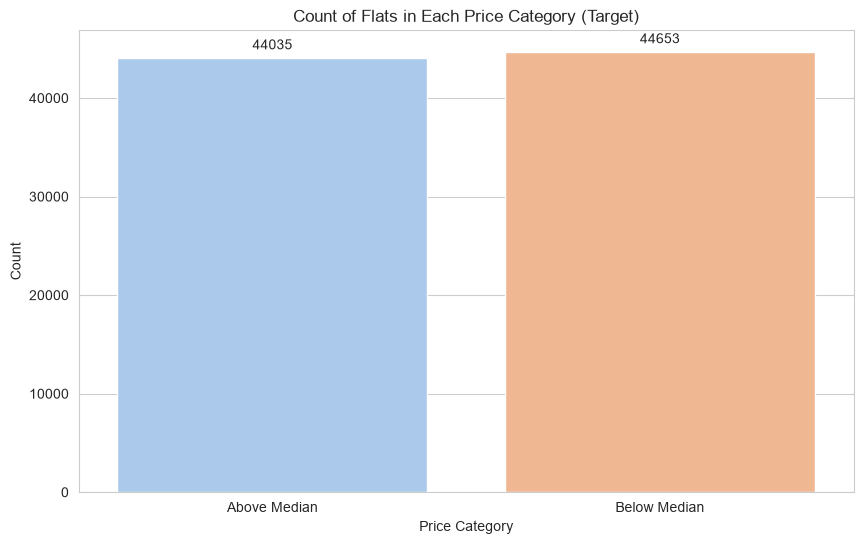

In [50]:
# Set the aesthetic style of the plots
sns.set_style("whitegrid")

# Bar chart for price category with annotations
plt.figure(figsize=(10, 6))
count_plot = sns.countplot(x='price_category', data=df, palette='pastel')
plt.title('Count of Flats in Each Price Category (Target)')
plt.xlabel('Price Category')
plt.ylabel('Count')
#plt.xticks(rotation=45)

# Annotate the bars with the frequency count
for p in count_plot.patches:
    count_plot.annotate(format(p.get_height(), '.0f'),
                        (p.get_x() + p.get_width() / 2., p.get_height()),
                        ha = 'center', va = 'center',
                        xytext = (0, 9),
                        textcoords = 'offset points')

plt.show()

In [51]:
# Encode the target column
df['price_category'] = df['price_category'].map({'Above Median': 1, 'Below Median': 0})

# Check the distribution of the target column
df['price_category'].value_counts()

price_category
0    44653
1    44035
Name: count, dtype: int64

In [52]:
# Separate the data into features and target
X = df.drop(columns='price_category')
y = df['price_category']

# Split the data into training (80%) and test-validation (20%) sets
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Split the test-validation set (20%) into validation (10%) and test (10%) sets
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)

In [53]:
#Logistic Regression

# Create the pipeline with a logistic regression model
logreg_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),  # Use the preprocessor pipeline defined earlier
    ('classifier', LogisticRegression(max_iter=1000))
])

# Fit the pipeline to the training data
logreg_pipeline.fit(X_train, y_train)

# Predict on the validation set
y_val_pred = logreg_pipeline.predict(X_val)

In [54]:
logreg_pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](13,)","['id','month','flat_type',...,'flatm_id','town_name','flatm_name']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,13
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numerical', ...), ('categorical', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passth

In [55]:
# Calculate the classification metrics for Logistic Regression
logreg_val_accuracy = accuracy_score(y_val, y_val_pred)

# Display the metrics for Logistic Regression
print("Logistic Regression Metrics:")
print(f'LogReg Validation Accuracy: {logreg_val_accuracy:.5f}')

Logistic Regression Metrics:
LogReg Validation Accuracy: 0.93505


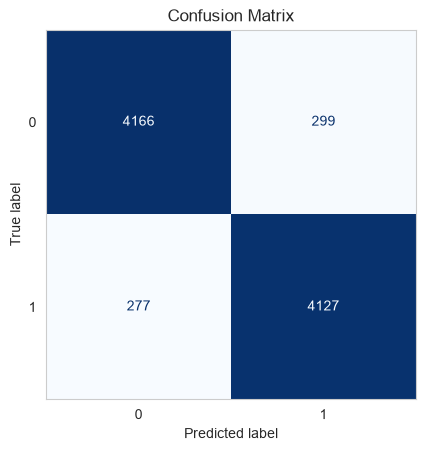

In [56]:
# Calculate the confusion matrix
cm = confusion_matrix(y_val, y_val_pred)

# Display the confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
fig, ax = plt.subplots()
disp.plot(cmap=plt.cm.Blues, ax=ax, colorbar=False)
plt.title("Confusion Matrix")
plt.grid(False)
plt.show()

In [57]:
# Calculate the classification metrics for Logistic Regression
logreg_val_precision = precision_score(y_val, y_val_pred)
logreg_val_recall = recall_score(y_val, y_val_pred)
logreg_val_f1 = f1_score(y_val, y_val_pred)

# Display the metrics for Logistic Regression
print("Logistic Regression Metrics:")
print(f'LogReg Validation Precision: {logreg_val_precision:.5f}')
print(f'LogReg Validation Recall: {logreg_val_recall:.5f}')
print(f'LogReg Validation F1 Score: {logreg_val_f1:.5f}')

Logistic Regression Metrics:
LogReg Validation Precision: 0.93244
LogReg Validation Recall: 0.93710
LogReg Validation F1 Score: 0.93477


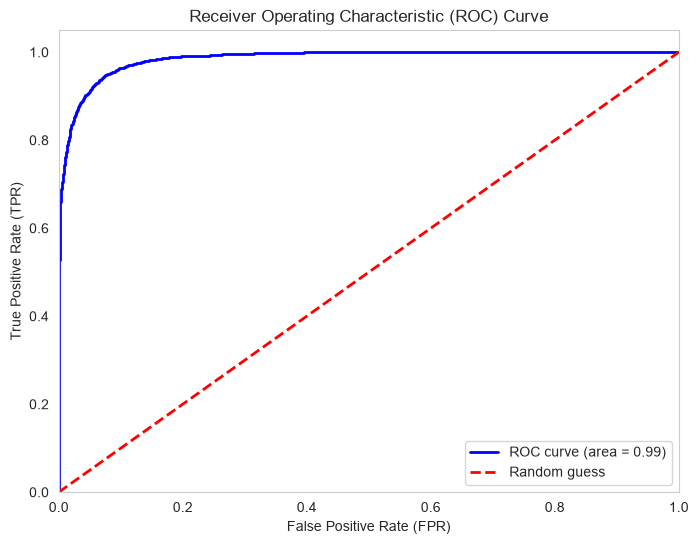

In [58]:

# Calculate the ROC curve
fpr, tpr, thresholds = roc_curve(y_val, logreg_pipeline.predict_proba(X_val)[:, 1])

# Calculate the AUC
roc_auc = roc_auc_score(y_val, logreg_pipeline.predict_proba(X_val)[:, 1])

# Plot the ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')  
plt.plot([0, 1], [0, 1], color='red', lw=2, linestyle='--', label='Random guess')  
plt.xlim([0.0, 1.0])  
plt.ylim([0.0, 1.05])  
plt.xlabel('False Positive Rate (FPR)')  
plt.ylabel('True Positive Rate (TPR)')  
plt.title('Receiver Operating Characteristic (ROC) Curve')  
plt.legend(loc='lower right')  
plt.grid()  
plt.show()

In [ ]:
#K Nearest Neighbours

# Create the pipeline with a KNN classifier
knn_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor), # Use the preprocessor pipeline defined earlier
    ('classifier', KNeighborsClassifier(n_neighbors=5)) # You can choose the number of neighbors (k) as desired
])

# Fit the pipeline to the training data
knn_pipeline.fit(X_train, y_train)

# Predict on the validation set
y_val_pred = knn_pipeline.predict(X_val)
y_val_pred_proba = knn_pipeline.predict_proba(X_val)[:, 1]

In [60]:
# Calculate and print the classification metrics for the KNN model
val_accuracy = accuracy_score(y_val, y_val_pred)
val_precision = precision_score(y_val, y_val_pred)
val_recall = recall_score(y_val, y_val_pred)
val_f1 = f1_score(y_val, y_val_pred)
val_roc_auc = roc_auc_score(y_val, y_val_pred_proba)

print("K-Nearest Neighbors (KNN) Metrics:")
print(f'Validation Accuracy: {val_accuracy:.5f}')
print(f'Validation Precision: {val_precision:.5f}')  
print(f'Validation Recall: {val_recall:.5f}')  
print(f'Validation F1 Score: {val_f1:.5f}')  
print(f'Validation ROC AUC: {val_roc_auc:.5f}')

K-Nearest Neighbors (KNN) Metrics:
Validation Accuracy: 0.92446
Validation Precision: 0.91955
Validation Recall: 0.92916
Validation F1 Score: 0.92433
Validation ROC AUC: 0.97087


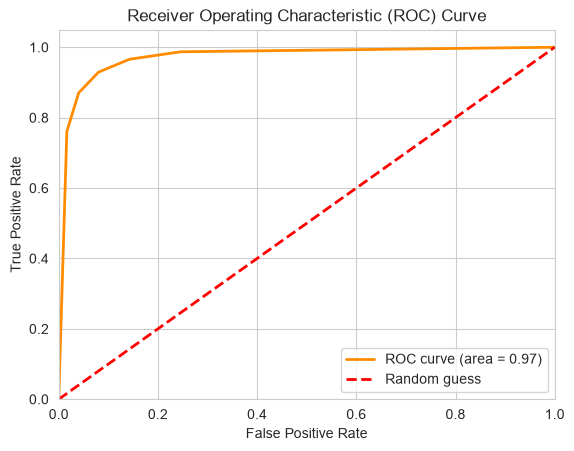

In [61]:
# Plot the ROC curve
fpr, tpr, thresholds = roc_curve(y_val, knn_pipeline.predict_proba(X_val)[:, 1])
roc_auc = roc_auc_score(y_val, knn_pipeline.predict_proba(X_val)[:, 1])

plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')  
plt.plot([0, 1], [0, 1], color='red', lw=2, linestyle='--', label='Random guess')  
plt.xlim([0.0, 1.0])  
plt.ylim([0.0, 1.05])  
plt.xlabel('False Positive Rate')  
plt.ylabel('True Positive Rate')  
plt.title('Receiver Operating Characteristic (ROC) Curve')  
plt.legend(loc="lower right")  
plt.grid(True)  
plt.show()

In [63]:
#Decision Trees

from sklearn.tree import DecisionTreeClassifier

# Create the pipeline with a Decision Tree classifier
dt_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', DecisionTreeClassifier(criterion='gini', min_samples_split=2, max_depth=None, random_state=42))  
])

# Fit the pipeline to the training data
dt_pipeline.fit(X_train, y_train)

# Predict on the validation set
y_val_pred = dt_pipeline.predict(X_val)
y_val_pred_proba = dt_pipeline.predict_proba(X_val)[:, 1]

# Calculate metrics for the validation set
val_accuracy = accuracy_score(y_val, y_val_pred)
val_precision = precision_score(y_val, y_val_pred)  
val_recall = recall_score(y_val, y_val_pred)  
val_f1 = f1_score(y_val, y_val_pred)  
val_roc_auc = roc_auc_score(y_val, y_val_pred_proba)  

# Calculate metrics for the training set
y_train_pred = dt_pipeline.predict(X_train)  
y_train_pred_proba = dt_pipeline.predict_proba(X_train)[:, 1]  

train_accuracy = accuracy_score(y_train, y_train_pred)  
train_precision = precision_score(y_train, y_train_pred)  
train_recall = recall_score(y_train, y_train_pred)  
train_f1 = f1_score(y_train, y_train_pred)  
train_roc_auc = roc_auc_score(y_train, y_train_pred_proba)  

print("Decision Tree Classifier Validation Metrics:")
print(f'Validation Accuracy: {val_accuracy:.5f}')
print(f'Validation Precision: {val_precision:.5f}')  
print(f'Validation Recall: {val_recall:.5f}')  
print(f'Validation F1 Score: {val_f1:.5f}')  
print(f'Validation ROC AUC: {val_roc_auc:.5f}')  

print("Training Set Metrics:")
print(f'Training Accuracy: {train_accuracy:.5f}')  
print(f'Training Precision: {train_precision:.5f}')  
print(f'Training Recall: {train_recall:.5f}')  
print(f'Training F1 Score: {train_f1:.5f}')  
print(f'Training ROC AUC: {train_roc_auc:.5f}')

Decision Tree Classifier Validation Metrics:
Validation Accuracy: 0.92874
Validation Precision: 0.92631
Validation Recall: 0.93052
Validation F1 Score: 0.92841
Validation ROC AUC: 0.92886
Training Set Metrics:
Training Accuracy: 0.99961
Training Precision: 0.99991
Training Recall: 0.99929
Training F1 Score: 0.99960
Training ROC AUC: 1.00000


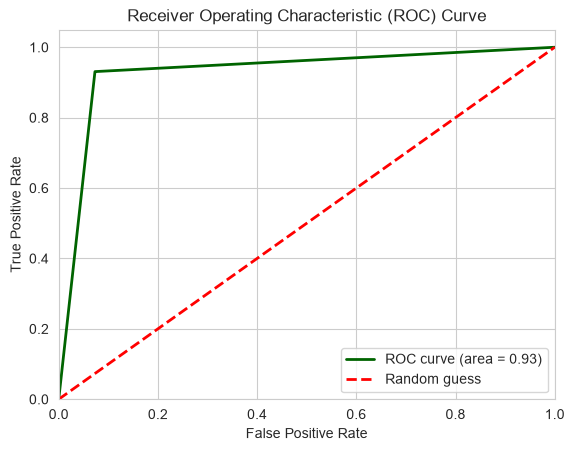

In [64]:
fpr, tpr, thresholds = roc_curve(y_val, y_val_pred_proba)
roc_auc = roc_auc_score(y_val, y_val_pred_proba)

plt.figure()  
plt.plot(fpr, tpr, color='darkgreen', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')  
plt.plot([0, 1], [0, 1], color='red', lw=2, linestyle='--', label='Random guess')  
plt.xlim([0.0, 1.0])  
plt.ylim([0.0, 1.05])  
plt.xlabel('False Positive Rate')  
plt.ylabel('True Positive Rate')  
plt.title('Receiver Operating Characteristic (ROC) Curve')  
plt.legend(loc="lower right")  
plt.grid(True)  
plt.show()

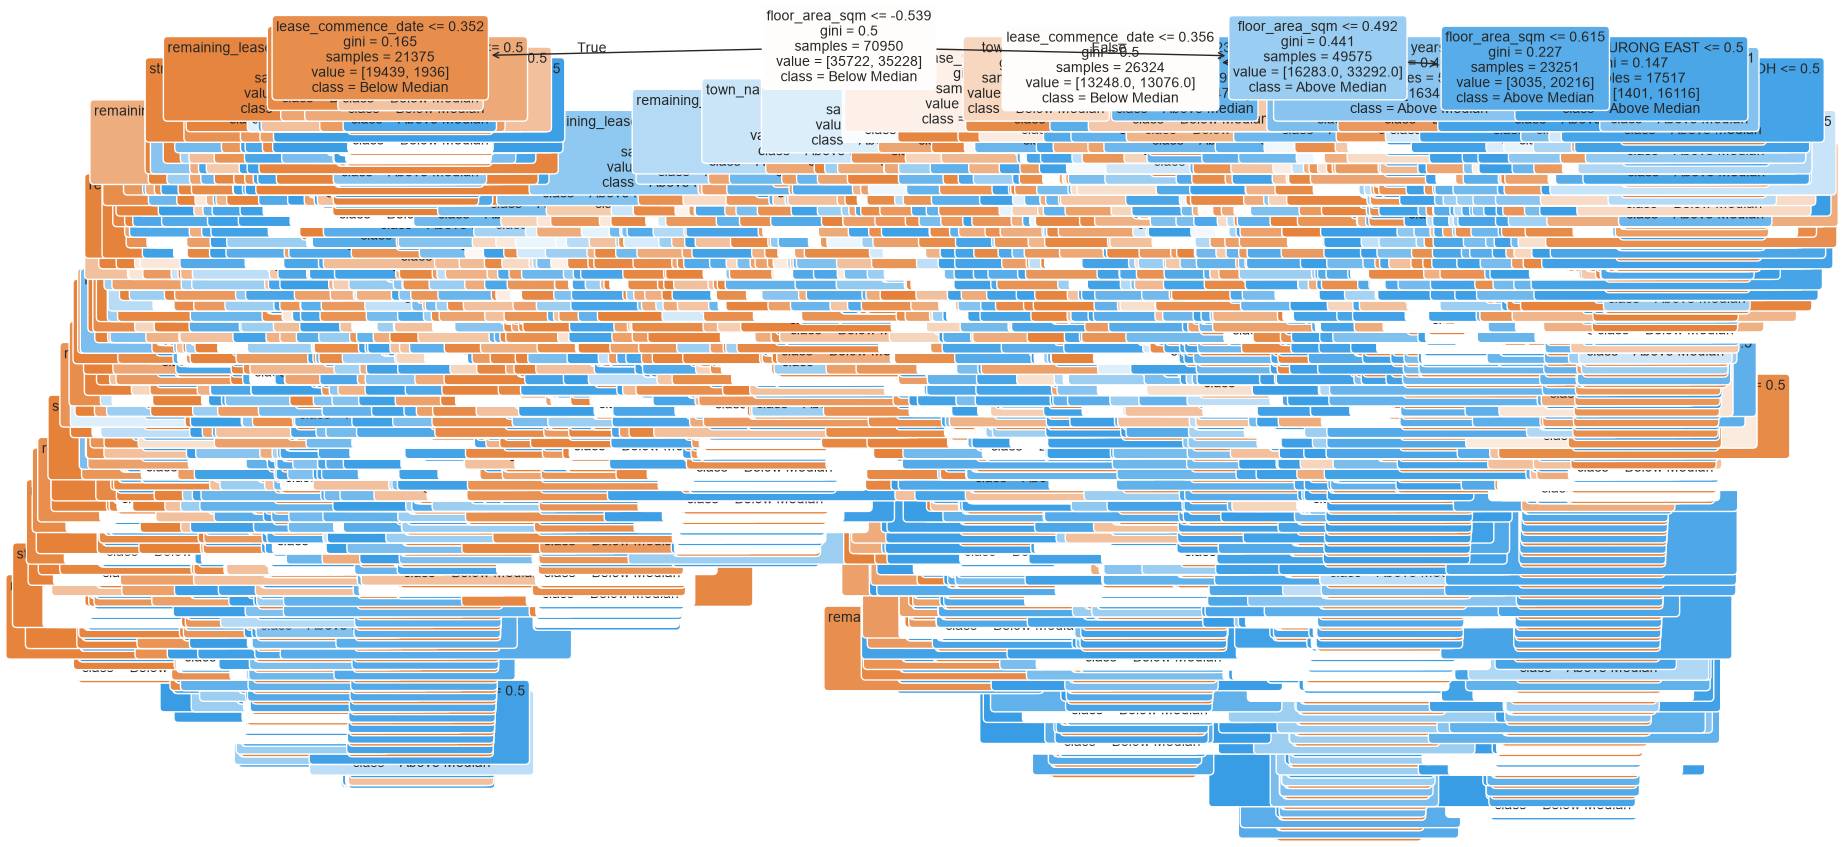

In [65]:
from sklearn.tree import plot_tree

# Extract the transformed feature names
feature_names = []
for name, transformer, columns in dt_pipeline.named_steps['preprocessor'].transformers_:
    if hasattr(transformer, 'named_steps'):
        for step in transformer.named_steps.values():
            if hasattr(step, 'get_feature_names_out'):
                feature_names.extend(step.get_feature_names_out(columns))
    elif hasattr(transformer, 'get_feature_names_out'):
        feature_names.extend(transformer.get_feature_names_out(columns))
    else:
        feature_names.extend(columns)
				
# Plot the decision tree
plt.figure(figsize=(20, 10))
plot_tree(dt_pipeline.named_steps['classifier'], feature_names=feature_names, class_names=['Below Median', 'Above Median'], filled=True, rounded=True, fontsize=10)
plt.show()

In [68]:

# Create the new pipeline with a Decision Tree classifier
# using max_depth as a pre-pruning parameter
dt_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', DecisionTreeClassifier(
        criterion='gini',
        min_samples_split=2,
        max_depth=5,
        min_samples_leaf=1,
        random_state=42
    ))
])

# Fit the new pipeline with pruning to the training data
dt_pipeline.fit(X_train, y_train)

# Predict on the validation set
y_val_pred_dt = dt_pipeline.predict(X_val)

# Calculate metrics for the validation set
val_accuracy = accuracy_score(y_val, y_val_pred_dt)
val_precision = precision_score(
    y_val, y_val_pred_dt, average='weighted'
)
val_recall = recall_score(
    y_val, y_val_pred_dt, average='weighted'
)
val_f1 = f1_score(
    y_val, y_val_pred_dt, average='weighted'
)

# Predict on the training set
y_train_pred_dt = dt_pipeline.predict(X_train)

# Calculate metrics for the training set
train_accuracy = accuracy_score(y_train, y_train_pred_dt)
train_precision = precision_score(
    y_train, y_train_pred_dt, average='weighted'
)
train_recall = recall_score(
    y_train, y_train_pred_dt, average='weighted'
)
train_f1 = f1_score(
    y_train, y_train_pred_dt, average='weighted'
)

print("Training Metrics")
print(f"Accuracy: {train_accuracy:.4f}")
print(f"Precision: {train_precision:.4f}")
print(f"Recall: {train_recall:.4f}")
print(f"F1-score: {train_f1:.4f}")

print("\nValidation Metrics")
print(f"Accuracy: {val_accuracy:.4f}")
print(f"Precision: {val_precision:.4f}")
print(f"Recall: {val_recall:.4f}")
print(f"F1-score: {val_f1:.4f}")

Training Metrics
Accuracy: 0.8208
Precision: 0.8446
Recall: 0.8208
F1-score: 0.8178

Validation Metrics
Accuracy: 0.8213
Precision: 0.8444
Recall: 0.8213
F1-score: 0.8184


In [72]:
#Hyperparameter tuning using GridSearch CV
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

# Create an untuned Decision Tree pipeline
dt_tuning_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', DecisionTreeClassifier(random_state=42))
])

# Hyperparameters to test
dt_param_grid = {
    'classifier__criterion': ['gini', 'entropy'],
    'classifier__max_depth': [3, 5, 10, None],
    'classifier__min_samples_split': [2, 5, 10],
    'classifier__min_samples_leaf': [1, 2, 5]
}

# Set up Grid Search with 5-fold cross-validation
dt_grid_search = GridSearchCV(
    estimator=dt_tuning_pipeline,
    param_grid=dt_param_grid,
    scoring='f1_weighted',
    cv=5,
    n_jobs=-1,
    verbose=1
)

# Search for the best hyperparameter combination
dt_grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 72 candidates, totalling 360 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'classifier__criterion': ['gini', 'entropy'], 'classifier__max_depth': [3, 5, ...], 'classifier__min_samples_leaf': [1, 2, ...], 'classifier__min_samples_split': [2, 5, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1_weighted'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more a

In [73]:
print("Best parameters:")
print(dt_grid_search.best_params_)

print("\nBest cross-validation F1-score:")
print(dt_grid_search.best_score_)

Best parameters:
{'classifier__criterion': 'entropy', 'classifier__max_depth': None, 'classifier__min_samples_leaf': 1, 'classifier__min_samples_split': 2}

Best cross-validation F1-score:
0.9230726627748052


In [74]:
best_dt_model = dt_grid_search.best_estimator_

# Make predictions
y_train_pred_tuned = best_dt_model.predict(X_train)
y_val_pred_tuned = best_dt_model.predict(X_val)

In [75]:
def calculate_metrics(y_actual, y_predicted):
    return {
        'Accuracy': accuracy_score(y_actual, y_predicted),
        'Precision': precision_score(
            y_actual,
            y_predicted,
            average='weighted',
            zero_division=0
        ),
        'Recall': recall_score(
            y_actual,
            y_predicted,
            average='weighted',
            zero_division=0
        ),
        'F1-score': f1_score(
            y_actual,
            y_predicted,
            average='weighted',
            zero_division=0
        )
    }

tuned_train_metrics = calculate_metrics(
    y_train, y_train_pred_tuned
)

tuned_val_metrics = calculate_metrics(
    y_val, y_val_pred_tuned
)

print("Tuned Decision Tree Training Metrics")
for metric, value in tuned_train_metrics.items():
    print(f"{metric}: {value:.4f}")

print("\nTuned Decision Tree Validation Metrics")
for metric, value in tuned_val_metrics.items():
    print(f"{metric}: {value:.4f}")

Tuned Decision Tree Training Metrics
Accuracy: 0.9996
Precision: 0.9996
Recall: 0.9996
F1-score: 0.9996

Tuned Decision Tree Validation Metrics
Accuracy: 0.9236
Precision: 0.9236
Recall: 0.9236
F1-score: 0.9236


In [76]:
comparison_df = pd.DataFrame({
    'Model': [
        'Original Decision Tree - Training',
        'Original Decision Tree - Validation',
        'Tuned Decision Tree - Training',
        'Tuned Decision Tree - Validation'
    ],
    'Accuracy': [
        train_accuracy,
        val_accuracy,
        tuned_train_metrics['Accuracy'],
        tuned_val_metrics['Accuracy']
    ],
    'F1-score': [
        train_f1,
        val_f1,
        tuned_train_metrics['F1-score'],
        tuned_val_metrics['F1-score']
    ]
})

comparison_df

,Model,Accuracy,F1-score
0,Original Decision Tree - Training,0.820761,0.817816
1,Original Decision Tree - Validation,0.821288,0.818435
2,Tuned Decision Tree - Training,0.999605,0.999605
3,Tuned Decision Tree - Validation,0.923554,0.923554
